In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
def analyze_hyperparameters(directory_path, plot_show=True, threshold=0.5):
    """
    Searches for a single CSV file in the given directory, performs analysis,
    generates visualizations, and saves the plots to a dedicated 'analysis_output'
    folder within that same directory.

    Args:
        directory_path (str): The path to the directory containing the CSV file.
        plot_show (bool): If True, displays the plots interactively.
        threshold (float): The value to subtract from the max accuracy to define
                         high-performing models for the summary.
    """
    # --- 1. Find the CSV file ---
    csv_files = glob.glob(os.path.join(directory_path, '*.csv'))

    if len(csv_files) == 1:
        file_path = csv_files[0]
        #print(f"Found CSV file: {file_path}")
    elif len(csv_files) == 0:
        print(f"Error: No CSV files found in '{directory_path}'.")
        return
    else:
        print(f"Error: More than one CSV file found in '{directory_path}'. Please ensure there is only one.")
        print("Found files:", csv_files)
        return

    # --- 2. Define and Create Output Directory ---
    output_dir = os.path.join(directory_path, 'analysis_output')
    os.makedirs(output_dir, exist_ok=True)
    print(f"\nOutput will be saved to: {output_dir}")

    # --- 3. Load Data ---
    try:
        df = pd.read_csv(file_path)
        #print(f"Successfully loaded data from '{file_path}'")
    except FileNotFoundError:
        # This is a fallback, though the glob check should prevent it.
        print(f"Error: The file '{file_path}' was not found.")
        return

    # --- 4. Correlation Analysis ---
    columns_to_correlate = ['gap', 'seq_num', 'hidden_size', 'num_layer', 'ACC']
    corr_matrix = df[columns_to_correlate].corr(method='spearman')

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        corr_matrix,
        annot=True,
        cmap='coolwarm',
        fmt=".2f",
        linewidths=.5
    )
    plt.title('Spearman Correlation Matrix of Parameters and Accuracy', fontsize=16)

    corr_save_path = os.path.join(output_dir, 'correlation_matrix.png')
    plt.savefig(corr_save_path, dpi=300, bbox_inches='tight')
    #print(f"Correlation matrix saved to '{corr_save_path}'")
    if plot_show:
        plt.show()
    else:
        plt.close()

    # --- 5. Visualize Impact of Window Size (seq_num) ---
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(20, 14))
    fig.suptitle('Impact of Window Size on Accuracy', fontsize=20)

    boxplot_props = {
        "showmeans": True,
        "meanprops": {
            "marker": "o",
            "markerfacecolor": "white",
            "markeredgecolor": "black",
            "markersize": "8"
        }
    }

    # Plot 1: Overall impact
    sns.boxplot(ax=axes[0, 0], x='seq_num', y='ACC', data=df, **boxplot_props)
    axes[0, 0].set_title('Overall Distribution', fontsize=16)
    axes[0, 0].set_xlabel('Window Size', fontsize=14)
    axes[0, 0].set_ylabel('Accuracy (%)', fontsize=14)
    axes[0, 0].grid(True, axis='y')

    # Plot 2: Grouped by Gap
    sns.boxplot(ax=axes[0, 1], x='seq_num', y='ACC', hue='gap', data=df, **boxplot_props)
    axes[0, 1].set_title('Grouped by Gap', fontsize=16)
    axes[0, 1].set_xlabel('Window Size', fontsize=14)
    axes[0, 1].set_ylabel('')
    axes[0, 1].grid(True, axis='y')
    axes[0, 1].legend(title='Gap')

    # Plot 3: Grouped by Hidden Size
    sns.boxplot(ax=axes[1, 0], x='seq_num', y='ACC', hue='hidden_size', data=df, **boxplot_props)
    axes[1, 0].set_title('Grouped by Hidden Size', fontsize=16)
    axes[1, 0].set_xlabel('Window Size', fontsize=14)
    axes[1, 0].set_ylabel('Accuracy (%)', fontsize=14)
    axes[1, 0].grid(True, axis='y')
    axes[1, 0].legend(title='Hidden Size')

    # Plot 4: Grouped by Number of Layers
    sns.boxplot(ax=axes[1, 1], x='seq_num', y='ACC', hue='num_layer', data=df, **boxplot_props)
    axes[1, 1].set_title('Grouped by Number of Layers', fontsize=16)
    axes[1, 1].set_xlabel('Window Size', fontsize=14)
    axes[1, 1].set_ylabel('')
    axes[1, 1].grid(True, axis='y')
    axes[1, 1].legend(title='Num Layers')

    for ax in axes.flatten():
        ax.tick_params(axis='both', which='major', labelsize=12)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

    impact_save_path = os.path.join(output_dir, 'window_size_impact.png')
    plt.savefig(impact_save_path, dpi=300, bbox_inches='tight')
    #print(f"Window size impact plot saved to '{impact_save_path}'")
    if plot_show:
        plt.show()
    else:
        plt.close()


    # --- 6. Summary Statistics ---
    high_accuracy_threshold = df.ACC.max() - threshold
    num_high_performers = df.loc[df.ACC > high_accuracy_threshold].shape[0]
    print(f"{num_high_performers} models reached accuracy over {high_accuracy_threshold:.2f}%. Highest Accuracy Recorded: {df.ACC.max():.4f}%")

    print(df.loc[df.ACC > high_accuracy_threshold])



def analyze_hyper_transformer(directory_path, plot_show=True, threshold=0.5):
    """
    Searches for a single hyperparameter results CSV file in the given directory,
    performs analysis tailored for the Transformer model, generates visualizations,
    and saves the plots to a dedicated 'analysis_output' folder.

    Args:
        directory_path (str): The path to the directory containing the CSV file.
        plot_show (bool): If True, displays the plots interactively.
        threshold (float): The value to subtract from the max accuracy to define
                           high-performing models for the summary.
    """
    # --- 1. Find the CSV file ---
    csv_files = glob.glob(os.path.join(directory_path, '*.csv'))

    if len(csv_files) == 1:
        file_path = csv_files[0]
    elif len(csv_files) == 0:
        print(f"Error: No CSV files found in '{directory_path}'.")
        return
    else:
        print(f"Error: More than one CSV file found in '{directory_path}'. Please ensure there is only one.")
        print("Found files:", csv_files)
        return

    # --- 2. Define and Create Output Directory ---
    output_dir = os.path.join(directory_path, 'analysis_output')
    os.makedirs(output_dir, exist_ok=True)
    print(f"\nAnalysis output will be saved to: {output_dir}")

    # --- 3. Load Data ---
    try:
        df = pd.read_csv(file_path)
    except FileNotFoundError:
        print(f"Error: The file '{file_path}' was not found.")
        return
    
    # Drop the 'dropout' column if it exists to clean the data
    if 'dropout' in df.columns:
        df.drop('dropout', axis=1, inplace=True)
    if 'weight_decay' in df.columns:
        df.drop('weight_decay', axis=1, inplace=True)
    if 'learning_rate' in df.columns:
        df.drop('learning_rate', axis=1, inplace=True)

    # --- 4. Correlation Analysis ---
    # ✅ CHANGED: Updated columns for Transformer hyperparameters
    columns_to_correlate = ['seq_num','d_model', 'n_head', 'num_layer', 'ACC']
    
    # Ensure all columns exist before trying to correlate
    valid_columns = [col for col in columns_to_correlate if col in df.columns]
    corr_matrix = df[valid_columns].corr(method='spearman')

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        corr_matrix,
        annot=True,
        cmap='coolwarm',
        fmt=".2f",
        linewidths=.5
    )
    plt.title('Spearman Correlation Matrix of Transformer Parameters and Accuracy', fontsize=16)

    corr_save_path = os.path.join(output_dir, 'correlation_matrix.png')
    plt.savefig(corr_save_path, dpi=300, bbox_inches='tight')
    if plot_show:
        plt.show()
    else:
        plt.close()

    # --- 5. Visualize Impact of Window Size (seq_num) ---
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(20, 14))
    fig.suptitle('Impact of Key Hyperparameters on Accuracy', fontsize=20)

    boxplot_props = {
        "showmeans": True,
        "meanprops": {
            "marker": "o", "markerfacecolor": "white",
            "markeredgecolor": "black", "markersize": "8"
        }
    }

    # Plot 1: Overall impact of window size
    sns.boxplot(ax=axes[0, 0], x='num_layer', y='ACC', data=df, **boxplot_props)
    axes[0, 0].set_title('Impact of Number of Number of Layers', fontsize=16)
    axes[0, 0].set_xlabel('Number of Layers', fontsize=14)
    axes[0, 0].set_ylabel('Accuracy (%)', fontsize=14)
    axes[0, 0].grid(True, axis='y')

    # Plot 2: Grouped by Model Dimension (d_model)
    # ✅ CHANGED: Replaced 'hidden_size' with 'd_model'
    sns.boxplot(ax=axes[0, 1], x='num_layer', y='ACC', hue='d_model', data=df, **boxplot_props)
    axes[0, 1].set_title('Grouped by Model Dimension (d_model)', fontsize=16)
    axes[0, 1].set_xlabel('Number of Layers', fontsize=14)
    axes[0, 1].set_ylabel('')
    axes[0, 1].grid(True, axis='y')
    axes[0, 1].legend(title='d_model')

    # Plot 3: Grouped by Number of Attention Heads (n_head)
    # ✅ CHANGED: Replaced 'hidden_size' plot with 'n_head' plot
    sns.boxplot(ax=axes[1, 0], x='num_layer', y='ACC', hue='n_head', data=df, **boxplot_props)
    axes[1, 0].set_title('Grouped by Attention Heads (n_head)', fontsize=16)
    axes[1, 0].set_xlabel('Number of Layers', fontsize=14)
    axes[1, 0].set_ylabel('Accuracy (%)', fontsize=14)
    axes[1, 0].grid(True, axis='y')
    axes[1, 0].legend(title='n_head')

    # Plot 4: Grouped by Number of Attention Heads (n_head)
    # ✅ CHANGED: Replaced 'hidden_size' plot with 'seq_num' plot
    sns.boxplot(ax=axes[1, 1], x='num_layer', y='ACC', hue='seq_num', data=df, **boxplot_props)
    axes[1, 1].set_title('Grouped by Window Size', fontsize=16)
    axes[1, 1].set_xlabel('Number of Layers', fontsize=14)
    axes[1, 1].set_ylabel('Accuracy (%)', fontsize=14)
    axes[1, 1].grid(True, axis='y')
    axes[1, 1].legend(title='Window Size')
    for ax in axes.flatten():
        ax.tick_params(axis='both', which='major', labelsize=12)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

    impact_save_path = os.path.join(output_dir, 'hyperparameter_impact.png')
    plt.savefig(impact_save_path, dpi=300, bbox_inches='tight')
    if plot_show:
        plt.show()
    else:
        plt.close()


    # --- 6. Summary Statistics ---
    if not df.empty and 'ACC' in df.columns:
        max_acc = df.ACC.max()
        high_accuracy_threshold = max_acc - threshold
        high_performers_df = df.loc[df.ACC >= high_accuracy_threshold].sort_values(by='ACC', ascending=False)
        
        print("\n" + "="*50)
        print("HYPERPARAMETER ANALYSIS SUMMARY")
        print("="*50)
        print(f"Highest Accuracy Recorded: {max_acc:.4f}%")
        print(f"\nDisplaying {len(high_performers_df)} models with accuracy >= {high_accuracy_threshold:.2f}%:")
        print(high_performers_df.to_string())
    else:
        print("\nCould not generate summary statistics. DataFrame might be empty or missing 'ACC' column.")




# Source Robot: Franka_main


Analysis output will be saved to: trained_models/franka_main/contact_detection_transformer/64/analysis_output


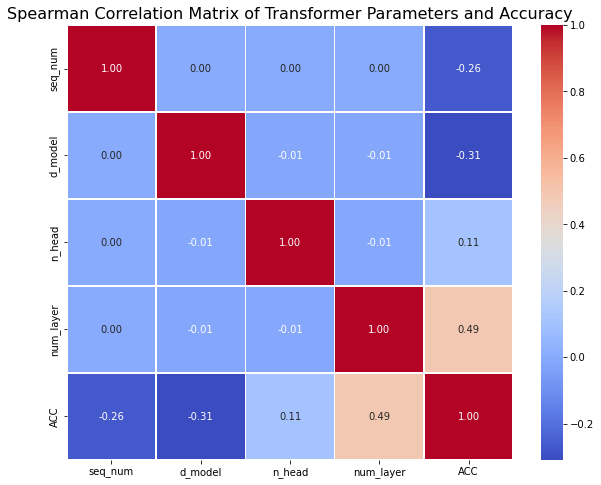

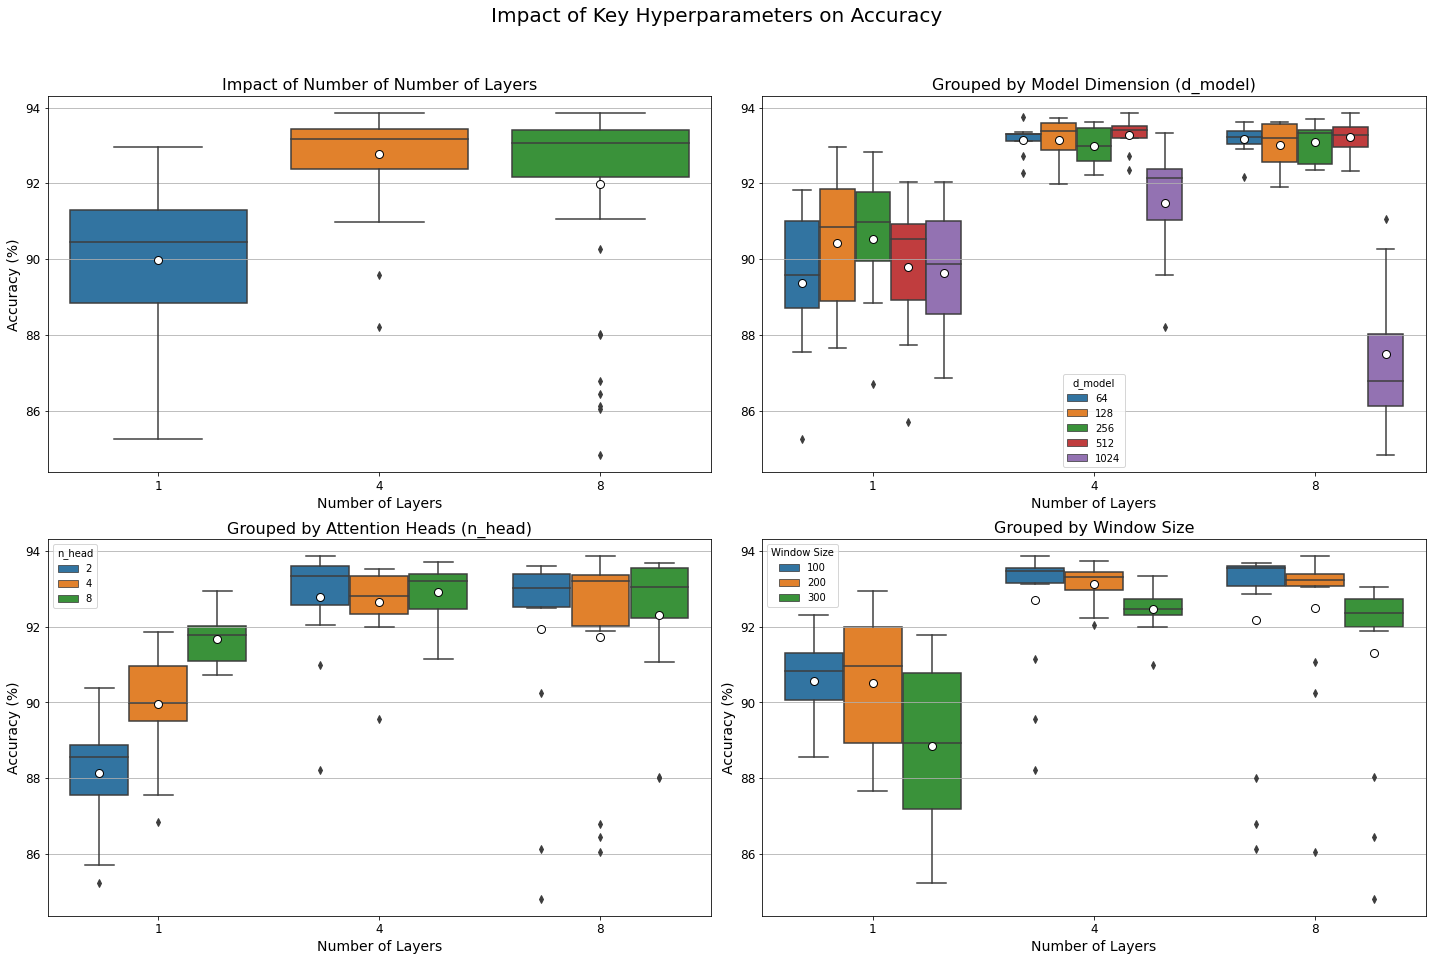


HYPERPARAMETER ANALYSIS SUMMARY
Highest Accuracy Recorded: 93.8560%

Displaying 6 models with accuracy >= 93.66%:
    seq_num  d_model  n_head  num_layer        ACC
76      200      512       4          8  93.856035
28      100      512       2          4  93.855947
45      200       64       2          4  93.743580
60      200      128       8          4  93.711141
26      100      256       8          8  93.686647
35      100      512       8          8  93.671985


In [5]:
#analyze_hyperparameters(directory_path='trained_models/franka_main/contact_detection_v2', plot_show= False, threshold=0.05)#
#analyze_hyperparameters(directory_path='trained_models/franka_main/contact_detection_v3/64', plot_show= False, threshold=0.2)
analyze_hyper_transformer(directory_path='trained_models/franka_main/contact_detection_transformer/64', plot_show= True, threshold=0.2)



Analysis output will be saved to: trained_models/franka_main/contact_localization_transformer/64/analysis_output


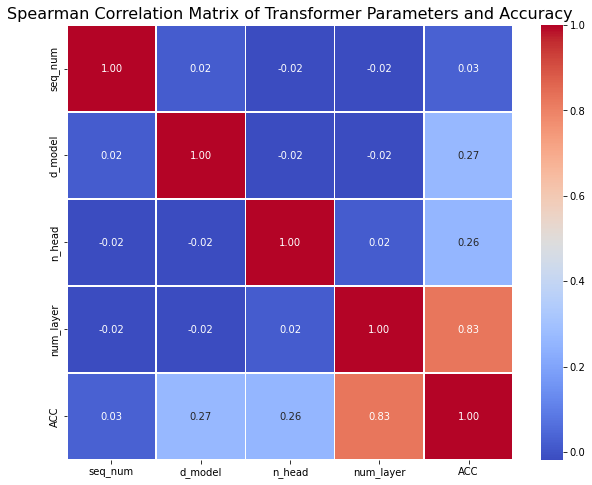

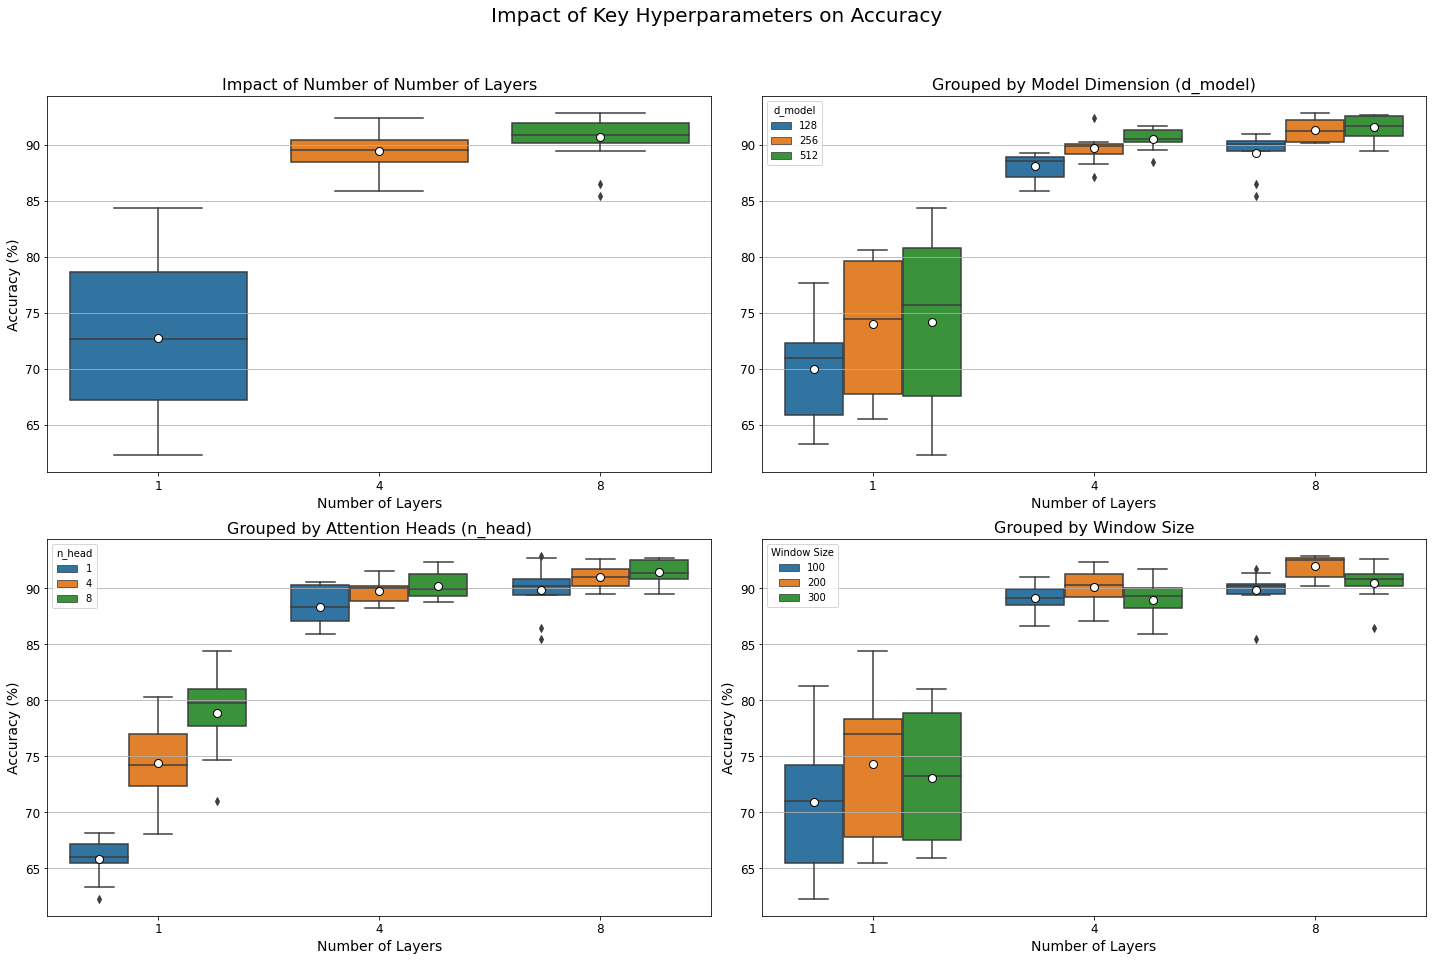


HYPERPARAMETER ANALYSIS SUMMARY
Highest Accuracy Recorded: 92.8648%

Displaying 3 models with accuracy >= 92.66%:
    seq_num  gap  d_model  n_head  num_layer        ACC  train_size  val_size
38      200    1      256       1          8  92.864814     1023017     92481
53      200    1      512       8          8  92.718129     1023017     92481
47      200    1      512       1          8  92.710271     1023017     92481


In [3]:
#analyze_hyperparameters(directory_path='trained_models/franka_main/contact_localization_v2', plot_show= False, threshold=0.08)
#analyze_hyperparameters(directory_path='trained_models/franka_main/contact_localization_v3/67', plot_show= False, threshold=0.2)
analyze_hyper_transformer(directory_path='trained_models/franka_main/contact_localization_transformer/64', plot_show= True, threshold=0.2)

# Target Robot: Franka_Mindlab

In [105]:
analyze_hyperparameters(directory_path='trained_models/franka_mindlab/contact_detection_v2', plot_show= False, threshold=0.02)
analyze_hyperparameters(directory_path='trained_models/franka_mindlab/contact_detection_v3/64', plot_show= False, threshold=0.2)


Output will be saved to: trained_models/franka_mindlab/contact_detection_v2/analysis_output
2 models reached accuracy over 96.70%. Highest Accuracy Recorded: 96.7215%
     gap  seq_num  hidden_size  num_layer        ACC
90     3      200           32          1  96.721549
105    3      200         1024          1  96.714296

Output will be saved to: trained_models/franka_mindlab/contact_detection_v3/64/analysis_output
2 models reached accuracy over 88.61%. Highest Accuracy Recorded: 88.8132%
     gap  seq_num  hidden_size  num_layer        ACC  train_size  val_size
154    3      100          256          2  88.662159       13792      8282
217   10      150           32          2  88.813181        4041      8072


In [104]:
analyze_hyperparameters(directory_path='trained_models/franka_mindlab/contact_localization_v2', plot_show= False, threshold=0.03)
analyze_hyperparameters(directory_path='trained_models/franka_mindlab/contact_localization_v3', plot_show= False, threshold=0.08)


Output will be saved to: trained_models/franka_mindlab/contact_localization_v2/analysis_output
3 models reached accuracy over 99.85%. Highest Accuracy Recorded: 99.8796%
     gap  seq_num  hidden_size  num_layer        ACC  train_size_localization  \
135    3      300          256          1  99.879639                     4984   
138    3      300          512          1  99.859579                     4984   
139    3      300          512          2  99.859579                     4984   

     train_size_detection  
135                 26874  
138                 26874  
139                 26874  

Output will be saved to: trained_models/franka_mindlab/contact_localization_v3/analysis_output
2 models reached accuracy over 87.58%. Highest Accuracy Recorded: 87.6638%
     seq_num  gap  hidden_size  num_layer        ACC  train_size  val_size
257      300    3           64          3  87.625289        4598      2594
272      300    5          128          3  87.663840        2760      2

# Target Robot: UR5

In [100]:
analyze_hyperparameters(directory_path='trained_models/ur5/contact_detection_v2', plot_show= False, threshold=0.2)
analyze_hyperparameters(directory_path='trained_models/ur5/contact_detection_v3/64/', plot_show= False, threshold=0.08)


Output will be saved to: trained_models/ur5/contact_detection_v2/analysis_output
3 models reached accuracy over 94.14%. Highest Accuracy Recorded: 94.3411%
     gap  seq_num  hidden_size  num_layer        ACC
122    3      250          512          3  94.185308
126    3      300           32          1  94.341075
130    3      300           64          2  94.155011

Output will be saved to: trained_models/ur5/contact_detection_v3/64/analysis_output
2 models reached accuracy over 84.24%. Highest Accuracy Recorded: 84.3187%
     gap  seq_num  hidden_size  num_layer        ACC  train_size  val_size
117    5       80          256          1  84.311278        9607      9612
155    3      100          256          3  84.318658       15888      9540


In [96]:
analyze_hyperparameters(directory_path='trained_models/ur5/contact_localization_v2', plot_show= False, threshold=0.04)
analyze_hyperparameters(directory_path='trained_models/ur5/contact_localization_v3', plot_show= False, threshold=0.4)


Output will be saved to: trained_models/ur5/contact_localization_v2/analysis_output
2 models reached accuracy over 99.23%. Highest Accuracy Recorded: 99.2718%
     gap  seq_num  hidden_size  num_layer        ACC  train_size_localization  \
132    3      300          128          1  99.247573                     4119   
134    3      300          128          3  99.271845                     4119   

     train_size_detection  
132                 31172  
134                 31172  

Output will be saved to: trained_models/ur5/contact_localization_v3/analysis_output
2 models reached accuracy over 86.25%. Highest Accuracy Recorded: 86.6473%
     seq_num  gap  hidden_size  num_layer        ACC  train_size  val_size
353      400   10           64          3  86.510129        1080      2172
379      450    5          128          2  86.647315        2155      2067
